In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import itertools

#configurar para mostrar las tablas completas y no cortadas horizontal y verticalmente
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Cargar el archivo CSV
df = pd.read_csv('../dataset/F1_Datos_limpios.csv', encoding='UTF-8', low_memory=False)

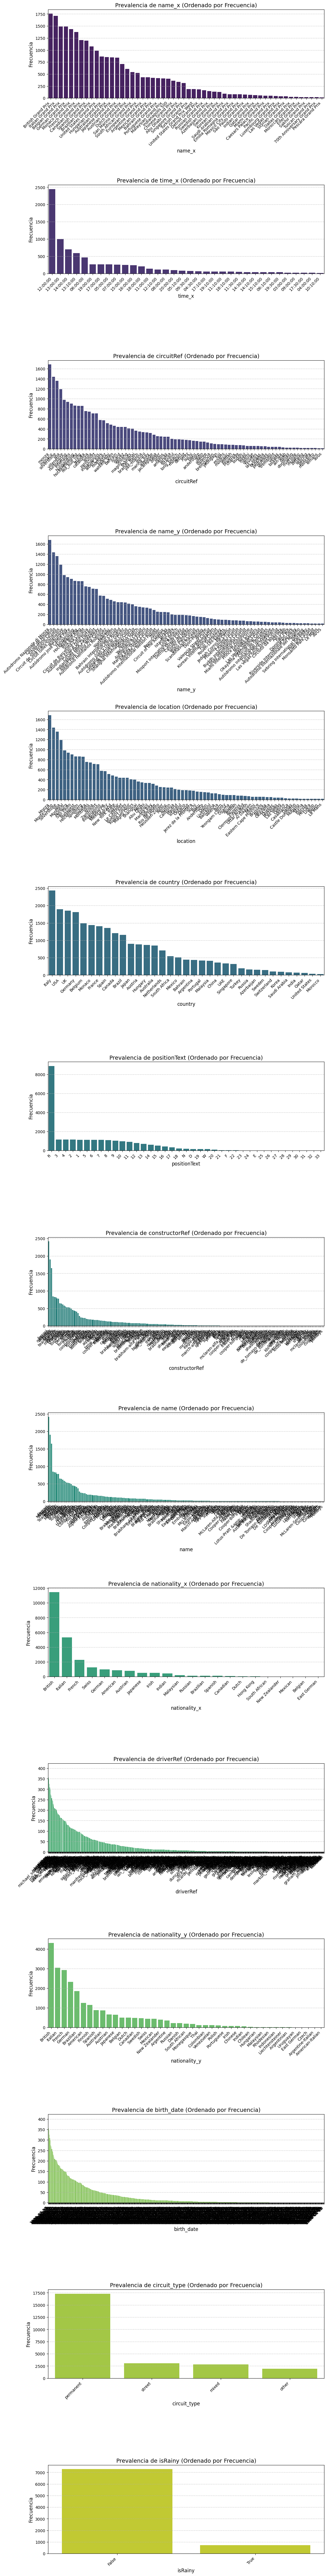

In [4]:
#prevalencia de variables categoricas
categoricas = df.select_dtypes(include=['object']).columns

# excluir variables redundantes o poco informativas
excluir = ['date', 'dob', 'time_y', 'fastestLapTime', 'forename', 'surname', 'race_datetime', 'result_datetime', 'race_weekday', 'code']
categoricas = [col for col in categoricas if col not in excluir]

#grafico de prevalencia de variables categoricas
def plot_categorical_prevalence_sorted_seaborn(df, categorical_columns):
    num_plots = len(categorical_columns)
    plt.figure(figsize=(12, num_plots * 6))

    # Define una lista de colores o una paleta para usar secuencialmente
    colors = sns.color_palette("viridis", n_colors=num_plots)

    for i, column in enumerate(categorical_columns):
        plt.subplot(num_plots, 1, i + 1)

        # 1. Calcular las frecuencias y obtener el orden de las categorías
        # value_counts() ya ordena de mayor a menor por defecto
        order_list = df[column].value_counts().index

        # 2. Usar el argumento 'order' en sns.countplot
        sns.countplot(data=df, x=column, order=order_list, color=colors[i % len(colors)])

        plt.title(f'Prevalencia de {column} (Ordenado por Frecuencia)', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Frecuencia', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(pad=3.0)
    plt.show()

# --- ¡Llamada a la función para mostrar los gráficos ordenados! ---
plot_categorical_prevalence_sorted_seaborn(df, categoricas)

# Matriz de correlaciones relevantes entre parametros, o solo las correlaciones mas importantes:

In [5]:
'''
Seleccionar solo las columnas numéricas
numeric_cols = df.select_dtypes(include=['number']).columns
df_numeric = df[numeric_cols]

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualizar la matriz de correlación con un mapa de calor (heatmap)
plt.figure(figsize=(30, 15))
sns.heatmap(correlation_matrix,
            annot=True,     # Muestra los valores de correlación en las celdas
            cmap='coolwarm', # Colores: 'coolwarm' para mostrar positivos/negativos
            fmt=".2f",      # Formato de los números a dos decimales
            linewidths=.5)  # Líneas entre las celdas
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=18)
plt.show()
'''

'\nSeleccionar solo las columnas numéricas\nnumeric_cols = df.select_dtypes(include=[\'number\']).columns\ndf_numeric = df[numeric_cols]\n\n# Calcular la matriz de correlación\ncorrelation_matrix = df_numeric.corr()\n\n# Visualizar la matriz de correlación con un mapa de calor (heatmap)\nplt.figure(figsize=(30, 15))\nsns.heatmap(correlation_matrix,\n            annot=True,     # Muestra los valores de correlación en las celdas\n            cmap=\'coolwarm\', # Colores: \'coolwarm\' para mostrar positivos/negativos\n            fmt=".2f",      # Formato de los números a dos decimales\n            linewidths=.5)  # Líneas entre las celdas\nplt.title(\'Matriz de Correlación de Variables Numéricas\', fontsize=18)\nplt.show()\n'

Es interesante observar la correlacion negativa entre los dnfs y el año, cuanto mas se moderniza la fomula 1, mas disminuyen los accidentes

# Clustering de pilotos y escuderias

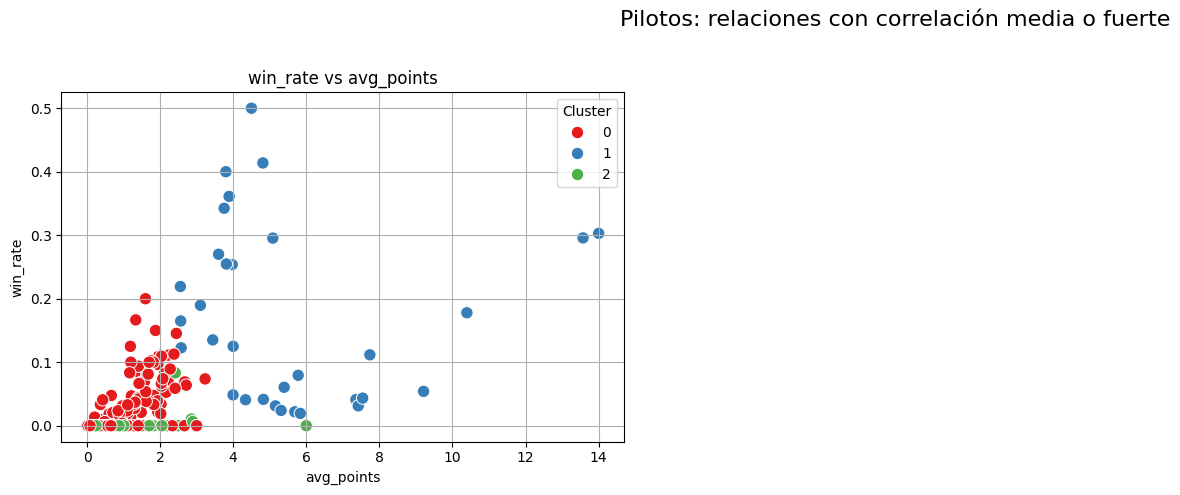

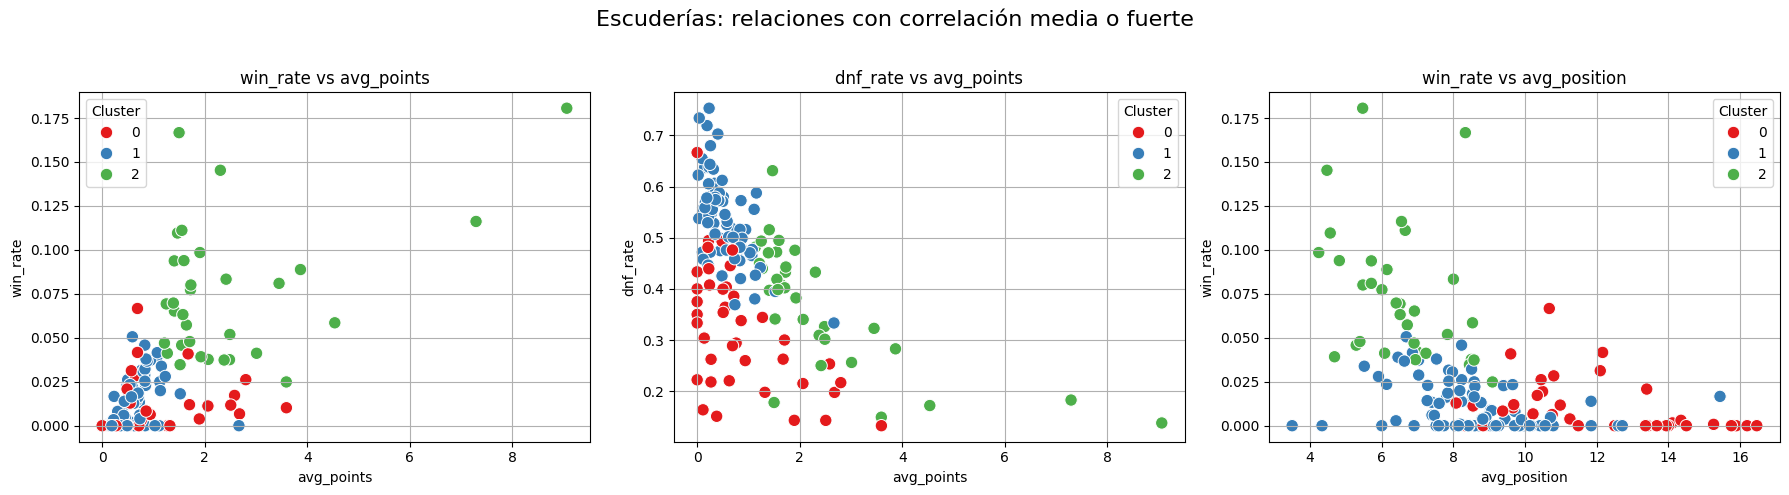

In [6]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
# --- Variables y configuración ---
features = [
    'avg_points', 'avg_position', 'win_rate', 'dnf_rate',
    'avg_gap_to_leader', 'avg_position_change'
]

# --- Agrupar pilotos ---
numeric_features = [col for col in features if pd.api.types.is_numeric_dtype(df[col])]
df_pilotos = df.groupby('driverRef')[numeric_features].mean().dropna()

scaler = StandardScaler()
X_pilotos_scaled = scaler.fit_transform(df_pilotos)

kmeans_pilotos = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_pilotos = kmeans_pilotos.fit_predict(X_pilotos_scaled)
df_pilotos['cluster'] = clusters_pilotos

# --- Agrupar escuderías ---
numeric_features_esc = [col for col in features if pd.api.types.is_numeric_dtype(df[col])]
df_esc = df.groupby('constructorRef')[numeric_features_esc].mean().dropna()

scaler_esc = StandardScaler()
X_esc_scaled = scaler_esc.fit_transform(df_esc)

kmeans_esc = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_esc = kmeans_esc.fit_predict(X_esc_scaled)
df_esc['cluster'] = clusters_esc
def plot_scatter_grid(df_clustered, title):
    corr = df_clustered.drop(columns='cluster').corr()
    selected_pairs = [
        (col1, col2)
        for col1, col2 in itertools.combinations(corr.columns, 2)
        if abs(corr.loc[col1, col2]) >= 0.5  # media/fuerte
    ]

    if not selected_pairs:
        selected_pairs = list(itertools.combinations(corr.columns, 2))

    n = len(selected_pairs)
    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, (x_var, y_var) in enumerate(selected_pairs):
        ax = axes[idx]
        sns.scatterplot(
            data=df_clustered, x=x_var, y=y_var, hue='cluster',
            palette='Set1', s=80, ax=ax
        )
        ax.set_title(f'{y_var} vs {x_var}')
        ax.legend(title='Cluster', loc='best')
        ax.grid(True)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Ejecutar ambos
plot_scatter_grid(df_pilotos, "Pilotos: relaciones con correlación media o fuerte")
plot_scatter_grid(df_esc, "Escuderías: relaciones con correlación media o fuerte")


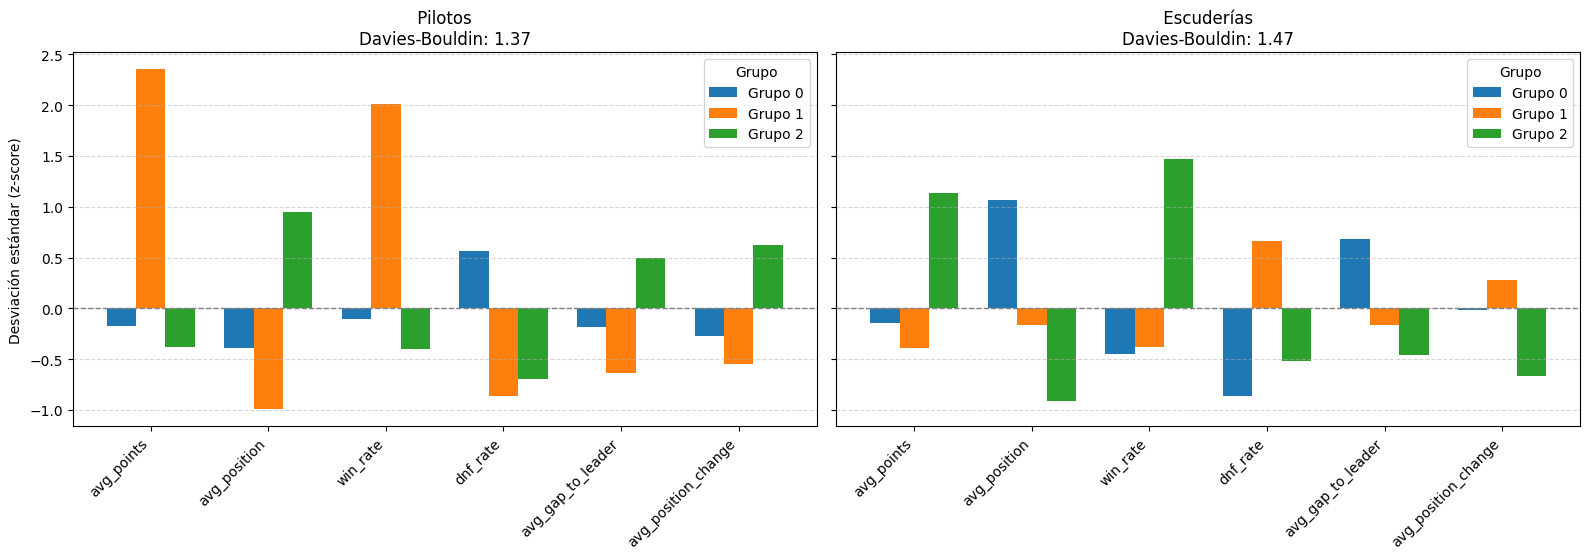

In [71]:
from sklearn.metrics import davies_bouldin_score

def plot_group_zscores_side_by_side(df1, df2, features, title1, title2):
    # Calcular promedios por grupo
    resumen1 = df1.groupby('cluster')[features].mean()
    resumen2 = df2.groupby('cluster')[features].mean()

    # Promedio y desvío general
    mean1 = df1[features].mean()
    std1 = df1[features].std()
    resumen1_z = (resumen1 - mean1) / std1

    mean2 = df2[features].mean()
    std2 = df2[features].std()
    resumen2_z = (resumen2 - mean2) / std2

    # Calcular DBI
    scaler = StandardScaler()
    X1 = scaler.fit_transform(df1[features])
    dbi1 = davies_bouldin_score(X1, df1['cluster'])

    X2 = scaler.fit_transform(df2[features])
    dbi2 = davies_bouldin_score(X2, df2['cluster'])

    # Configuración del gráfico
    grupos1 = resumen1_z.index
    grupos2 = resumen2_z.index
    x = np.arange(len(features))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # --- Primer gráfico (Pilotos) ---
    for i, grupo in enumerate(grupos1):
        axes[0].bar(x + i * width, resumen1_z.loc[grupo], width, label=f'Grupo {grupo}')
    axes[0].set_title(f'{title1}\nDavies-Bouldin: {dbi1:.2f}')
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(features, rotation=45, ha='right')
    axes[0].set_ylabel('Desviación estándar (z-score)')
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].legend(title='Grupo')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # --- Segundo gráfico (Escuderías) ---
    for i, grupo in enumerate(grupos2):
        axes[1].bar(x + i * width, resumen2_z.loc[grupo], width, label=f'Grupo {grupo}')
    axes[1].set_title(f'{title2}\nDavies-Bouldin: {dbi2:.2f}')
    axes[1].set_xticks(x + width)
    axes[1].set_xticklabels(features, rotation=45, ha='right')
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].legend(title='Grupo')
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Ejecutar la función para mostrar los gráficos comparativos
plot_group_zscores_side_by_side(
    df_pilotos, df_esc,
    features,
    title1=" Pilotos ",
    title2=" Escuderías "
)

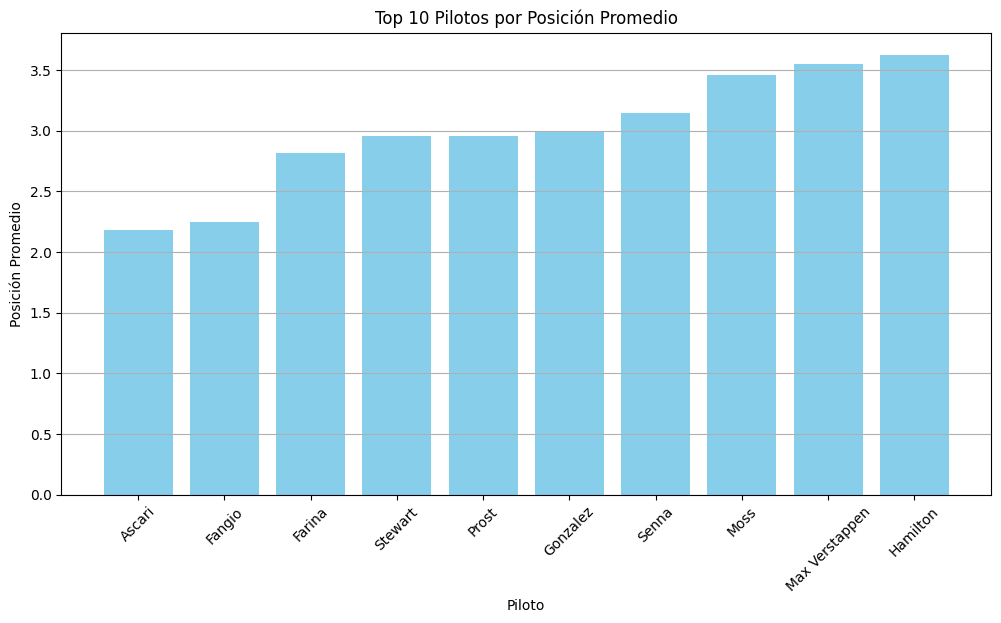

In [58]:
#grafico del top 10 pilotos por posicion promedio (con mas de 10 carreras)
top_10_pilotos = df[df['driverRef'].isin(df['driverRef'].value_counts()[df['driverRef'].value_counts() > 10].index)]
top_10_pilotos = top_10_pilotos.groupby('driverRef')['avg_position'].mean().reset_index()
top_10_pilotos = top_10_pilotos.sort_values(by='avg_position', ascending=True).head(10)
top_10_pilotos['Posición promedio'] = top_10_pilotos['avg_position']
top_10_pilotos['Piloto'] = top_10_pilotos['driverRef'].str.replace('_', ' ').str.title()
top_10_pilotos = top_10_pilotos[['Piloto', 'Posición promedio']]
# Graficar el top 10 pilotos por posición promedio

plt.figure(figsize=(12, 6))
plt.bar(top_10_pilotos['Piloto'], top_10_pilotos['Posición promedio'], color='skyblue')
plt.title('Top 10 Pilotos por Posición Promedio')
plt.xlabel('Piloto')
plt.ylabel('Posición Promedio')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

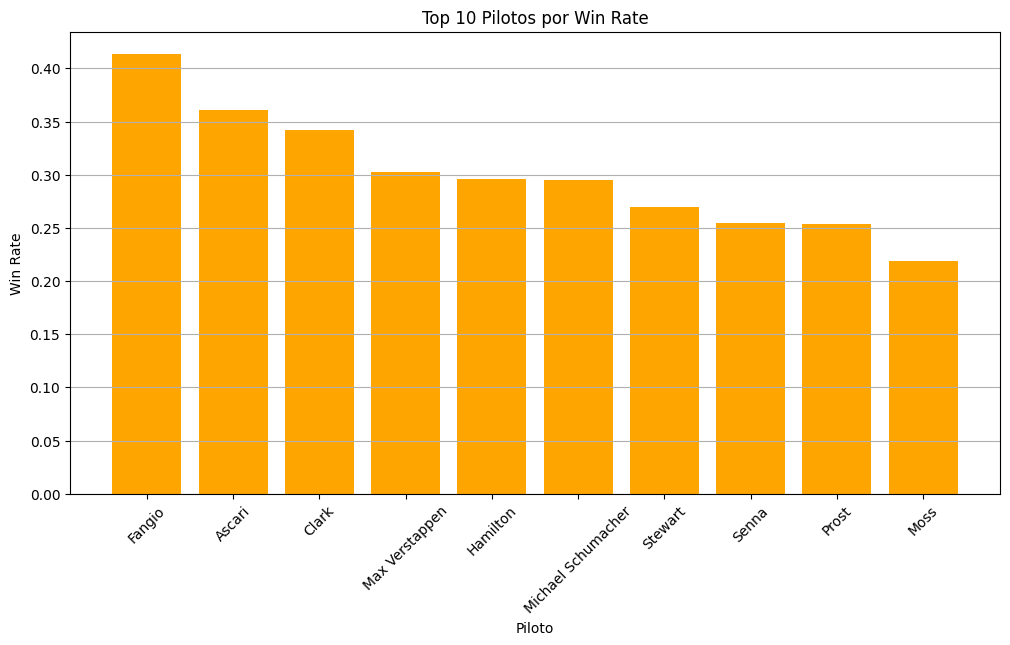

In [59]:
#top 10 pilotos por win_rate (con mas de 10 carreras)
top_10_pilotos_wr = df[df['driverRef'].isin(df['driverRef'].value_counts()[df['driverRef'].value_counts() > 10].index)]
top_10_pilotos_wr = top_10_pilotos_wr.groupby('driverRef')['win_rate'].mean().reset_index()
top_10_pilotos_wr = top_10_pilotos_wr.sort_values(by='win_rate', ascending=False).head(10)
top_10_pilotos_wr['Win Rate'] = top_10_pilotos_wr['win_rate']
top_10_pilotos_wr['Piloto'] = top_10_pilotos_wr['driverRef'].str.replace('_', ' ').str.title()
top_10_pilotos_wr = top_10_pilotos_wr[['Piloto', 'Win Rate']]
# Graficar el top 10 pilotos por win_rate
plt.figure(figsize=(12, 6))
plt.bar(top_10_pilotos_wr['Piloto'], top_10_pilotos_wr['Win Rate'], color='orange')
plt.title('Top 10 Pilotos por Win Rate')
plt.xlabel('Piloto')
plt.ylabel('Win Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

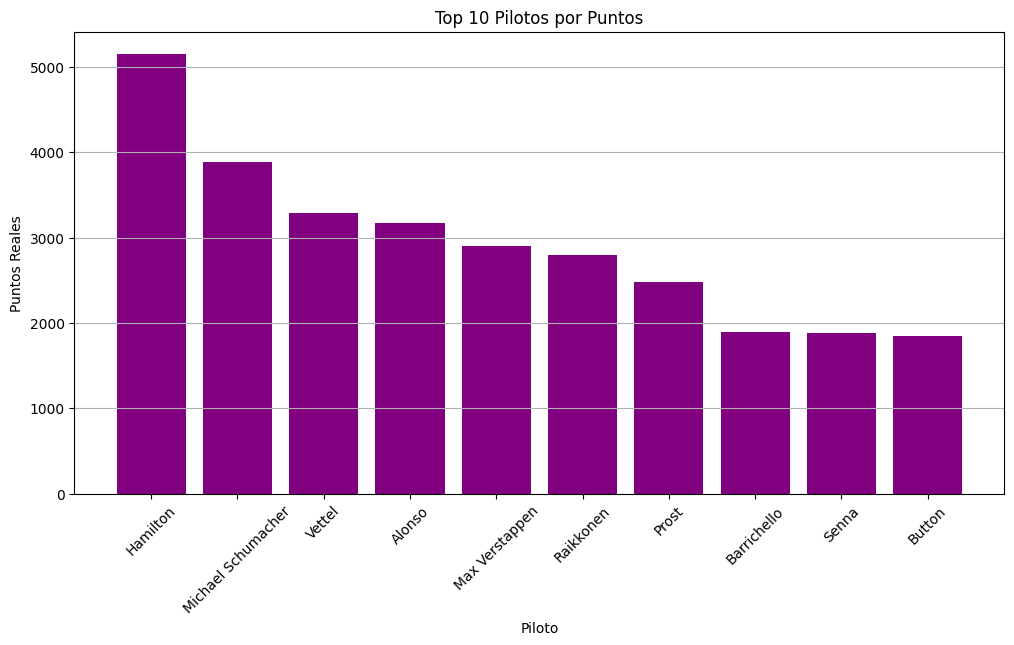

In [60]:
#top 10 pilotos por puntos reales y por promedio de puntos reales
top_10_pilotos_puntos = df
top_10_pilotos_puntos = top_10_pilotos_puntos.groupby('driverRef')['real_points'].sum().reset_index()
top_10_pilotos_puntos = top_10_pilotos_puntos.sort_values(by='real_points', ascending=False).head(10)
top_10_pilotos_puntos['Piloto'] = top_10_pilotos_puntos['driverRef'].str.replace('_', ' ').str.title()
top_10_pilotos_puntos = top_10_pilotos_puntos[['Piloto', 'real_points']]
# Graficar el top 10 pilotos por puntos reales
plt.figure(figsize=(12, 6))
plt.bar(top_10_pilotos_puntos['Piloto'], top_10_pilotos_puntos['real_points'], color='purple')
plt.title('Top 10 Pilotos por Puntos')
plt.xlabel('Piloto')
plt.ylabel('Puntos Reales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

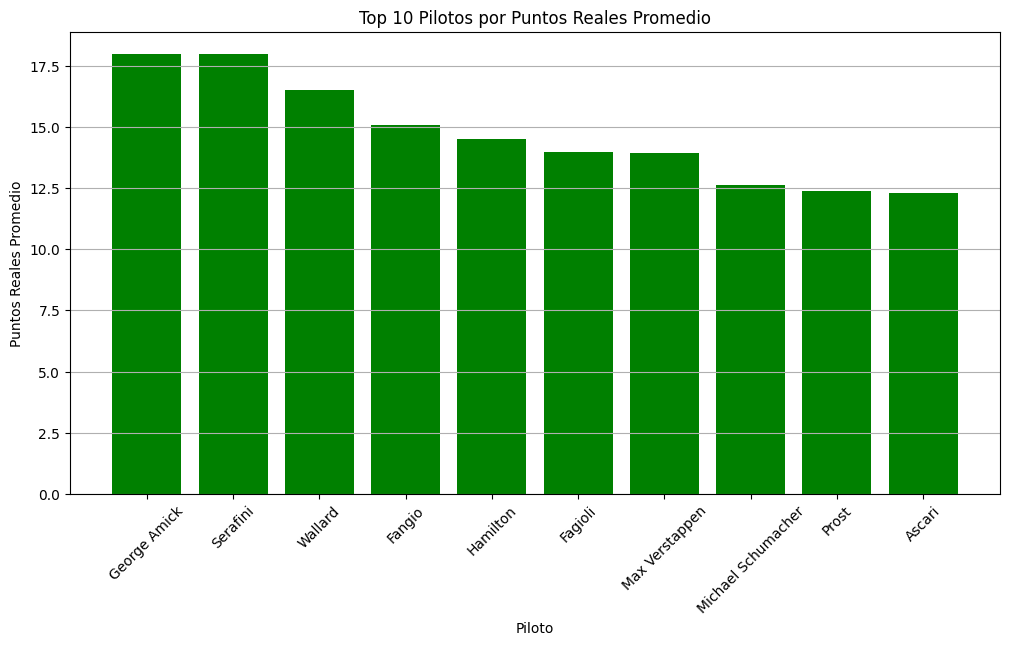

In [61]:
#grafico del top 10 pilotos por avg_real_points
top_10_pilotos_avg_puntos = df
top_10_pilotos_avg_puntos = top_10_pilotos_avg_puntos.groupby('driverRef')['avg_real_points'].mean().reset_index()
top_10_pilotos_avg_puntos = top_10_pilotos_avg_puntos.sort_values(by='avg_real_points', ascending=False).head(10)
top_10_pilotos_avg_puntos['Puntos Reales Promedio'] = top_10_pilotos_avg_puntos['avg_real_points']
top_10_pilotos_avg_puntos['Piloto'] = top_10_pilotos_avg_puntos['driverRef'].str.replace('_', ' ').str.title()
top_10_pilotos_avg_puntos = top_10_pilotos_avg_puntos[['Piloto', 'Puntos Reales Promedio']]
# Graficar el top 10 pilotos por avg_real_points
plt.figure(figsize=(12, 6))
plt.bar(top_10_pilotos_avg_puntos['Piloto'], top_10_pilotos_avg_puntos['Puntos Reales Promedio'], color='green')
plt.title('Top 10 Pilotos por Puntos Reales Promedio')
plt.xlabel('Piloto')
plt.ylabel('Puntos Reales Promedio')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

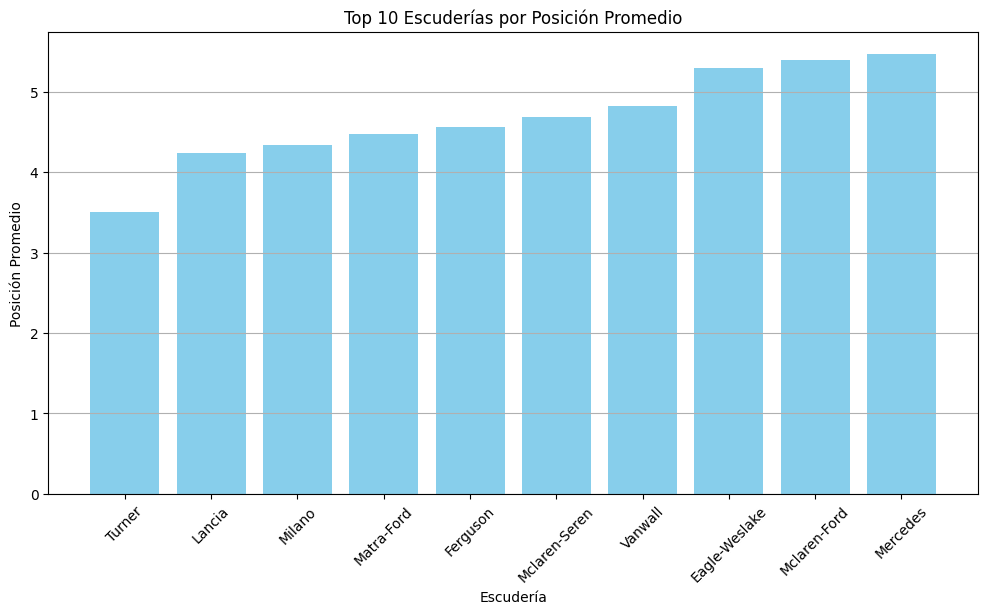

In [62]:
#top 10 escuderias por posicion promedio
top_10_escuderias = df
top_10_escuderias = top_10_escuderias.groupby('constructorRef')['avg_position'].mean().reset_index()
top_10_escuderias = top_10_escuderias.sort_values(by='avg_position', ascending=True).head(10)
top_10_escuderias['Posición promedio'] = top_10_escuderias['avg_position']
top_10_escuderias['Escudería'] = top_10_escuderias['constructorRef'].str.replace('_', ' ').str.title()
top_10_escuderias = top_10_escuderias[['Escudería', 'Posición promedio']]
# Graficar el top 10 escuderias por posición promedio
plt.figure(figsize=(12, 6))
plt.bar(top_10_escuderias['Escudería'], top_10_escuderias['Posición promedio'], color='skyblue')
plt.title('Top 10 Escuderías por Posición Promedio')
plt.xlabel('Escudería')
plt.ylabel('Posición Promedio')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

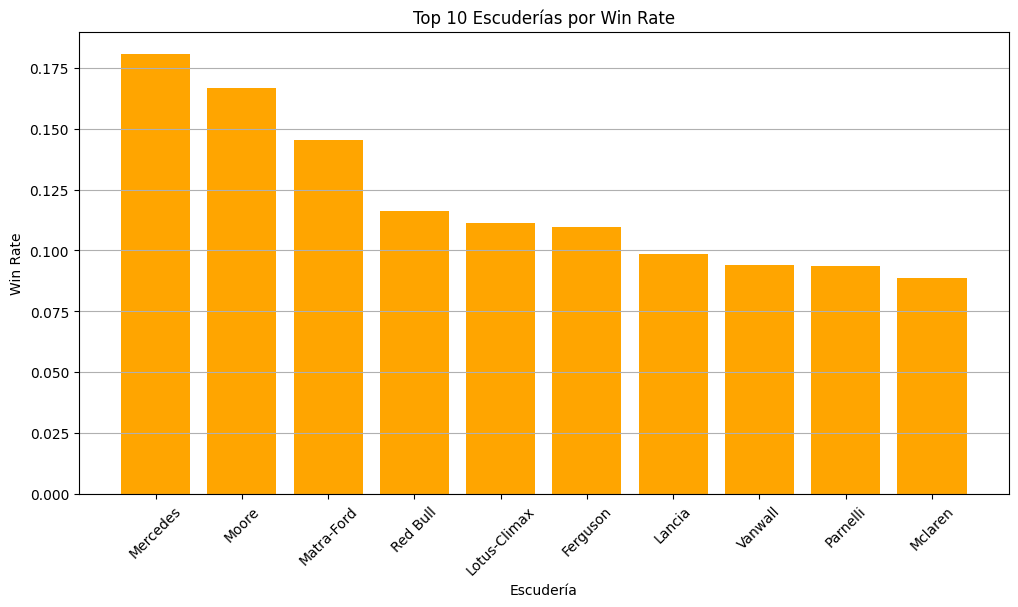

In [63]:
#top 10 escuderias por win_rate
top_10_escuderias_wr = df
top_10_escuderias_wr = top_10_escuderias_wr.groupby('constructorRef')['win_rate'].mean().reset_index()
top_10_escuderias_wr = top_10_escuderias_wr.sort_values(by='win_rate', ascending=False).head(10)
top_10_escuderias_wr['Win Rate'] = top_10_escuderias_wr['win_rate']
top_10_escuderias_wr['Escudería'] = top_10_escuderias_wr['constructorRef'].str.replace('_', ' ').str.title()
top_10_escuderias_wr = top_10_escuderias_wr[['Escudería', 'Win Rate']]
# Graficar el top 10 escuderias por win_rate
plt.figure(figsize=(12, 6))
plt.bar(top_10_escuderias_wr['Escudería'], top_10_escuderias_wr['Win Rate'], color='orange')
plt.title('Top 10 Escuderías por Win Rate')
plt.xlabel('Escudería')
plt.ylabel('Win Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

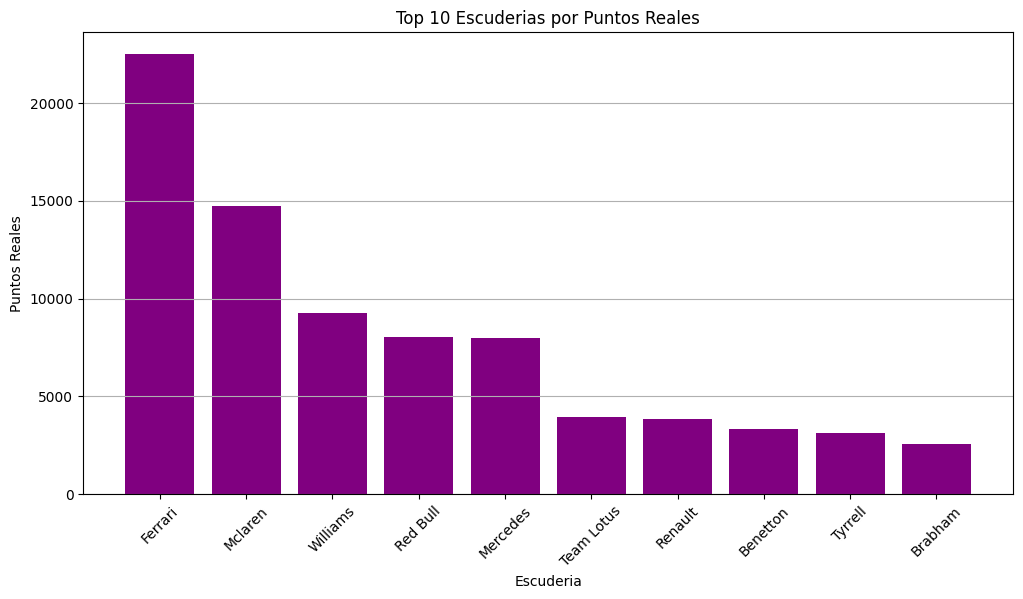

In [64]:
#top 10 escuderias por puntos reales
top_10_escuderias_puntos = df
top_10_escuderias_puntos = top_10_escuderias_puntos.groupby('constructorRef')['real_points'].sum().reset_index()
top_10_escuderias_puntos = top_10_escuderias_puntos.sort_values(by='real_points', ascending=False).head(10)
top_10_escuderias_puntos['Escuderia'] = top_10_escuderias_puntos['constructorRef'].str.replace('_', ' ').str.title()
top_10_escuderias_puntos = top_10_escuderias_puntos[['Escuderia', 'real_points']]
# Graficar el top 10 escuderias por puntos reales
plt.figure(figsize=(12, 6))
plt.bar(top_10_escuderias_puntos['Escuderia'], top_10_escuderias_puntos['real_points'], color='purple')
plt.title('Top 10 Escuderias por Puntos Reales')
plt.xlabel('Escuderia')
plt.ylabel('Puntos Reales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

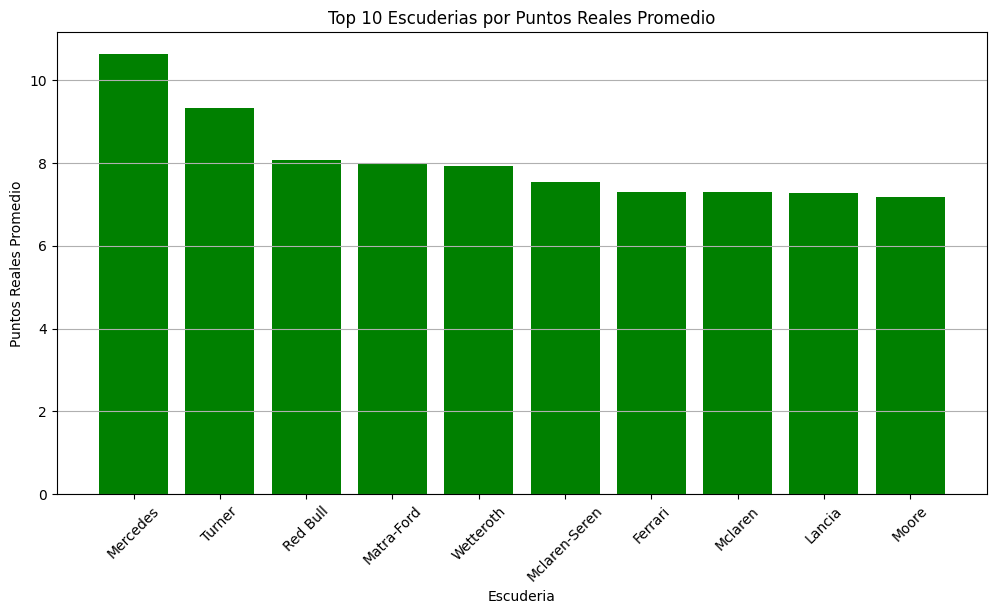

In [65]:
#top 10 escuderias por promedio de puntos reales
top_10_escuderias_avg_puntos = df
top_10_escuderias_avg_puntos = top_10_escuderias_avg_puntos.groupby('constructorRef')['avg_real_points'].mean().reset_index()
top_10_escuderias_avg_puntos = top_10_escuderias_avg_puntos.sort_values(by='avg_real_points', ascending=False).head(10)
top_10_escuderias_avg_puntos['Puntos Reales Promedio'] = top_10_escuderias_avg_puntos['avg_real_points']
top_10_escuderias_avg_puntos['Escuderia'] = top_10_escuderias_avg_puntos['constructorRef'].str.replace('_', ' ').str.title()
top_10_escuderias_avg_puntos = top_10_escuderias_avg_puntos[['Escuderia', 'Puntos Reales Promedio']]
# Graficar el top 10 escuderias por promedio de puntos reales
plt.figure(figsize=(12, 6))
plt.bar(top_10_escuderias_avg_puntos['Escuderia'], top_10_escuderias_avg_puntos['Puntos Reales Promedio'], color='green')
plt.title('Top 10 Escuderias por Puntos Reales Promedio')
plt.xlabel('Escuderia')
plt.ylabel('Puntos Reales Promedio')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Comparacion de circuitos

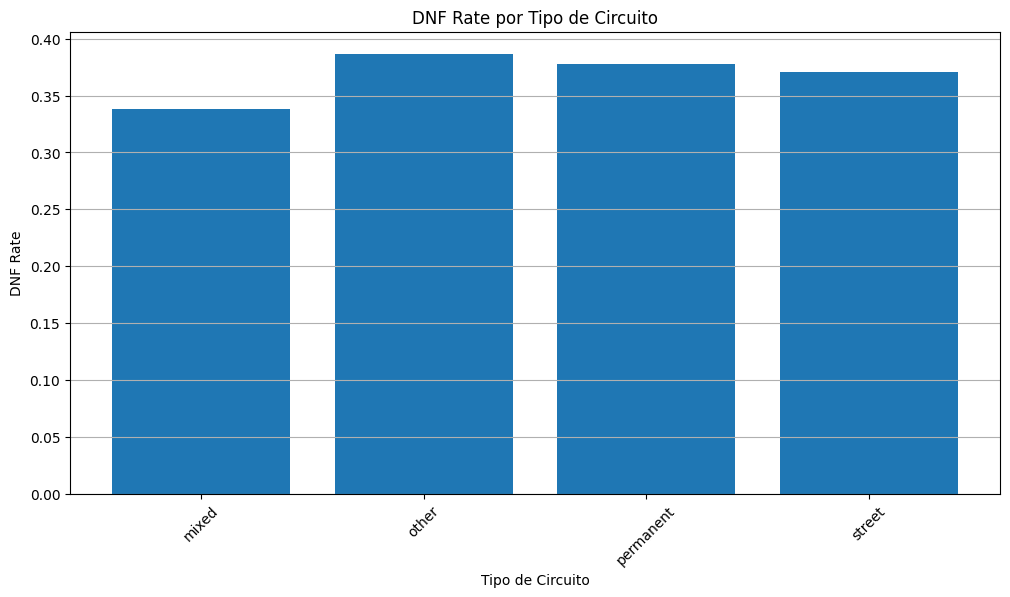

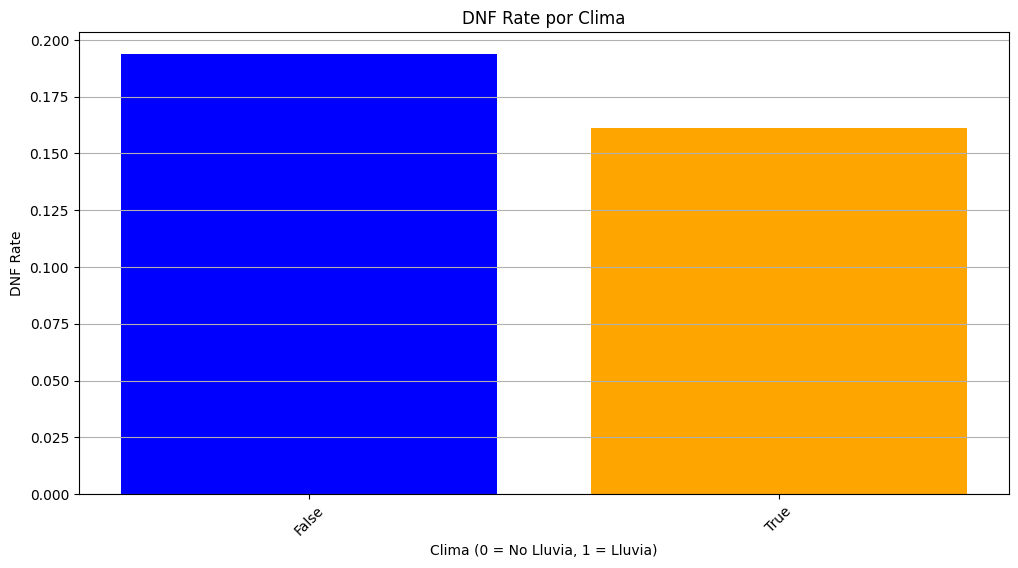

C:\Users\salva\AppData\Local\Temp\ipykernel_10776\789546019.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temperature_dnf_rate = df.groupby(temperature_bins)['dnf_rate'].mean().reset_index()


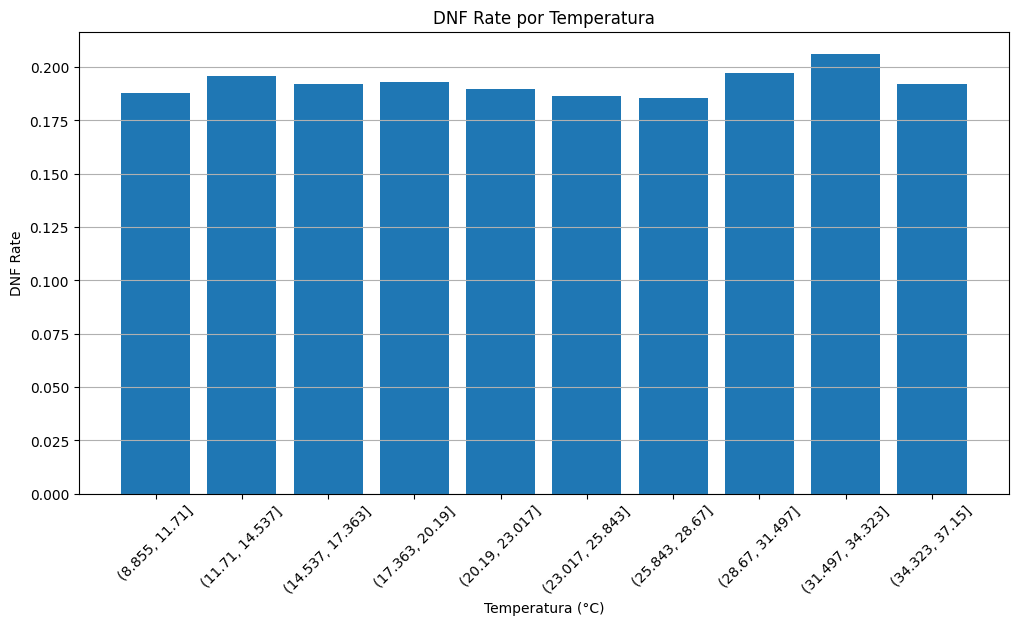

C:\Users\salva\AppData\Local\Temp\ipykernel_10776\789546019.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humidity_dnf_rate = df.groupby(humidity_bins)['dnf_rate'].mean().reset_index()


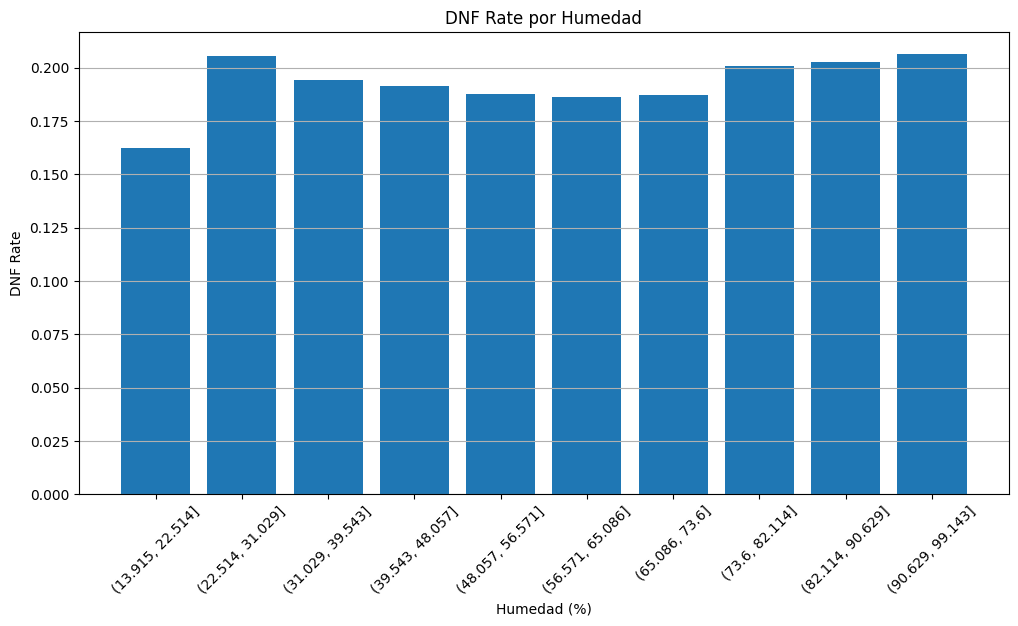

C:\Users\salva\AppData\Local\Temp\ipykernel_10776\789546019.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_speed_dnf_rate = df.groupby(wind_speed_bins)['dnf_rate'].mean().reset_index()


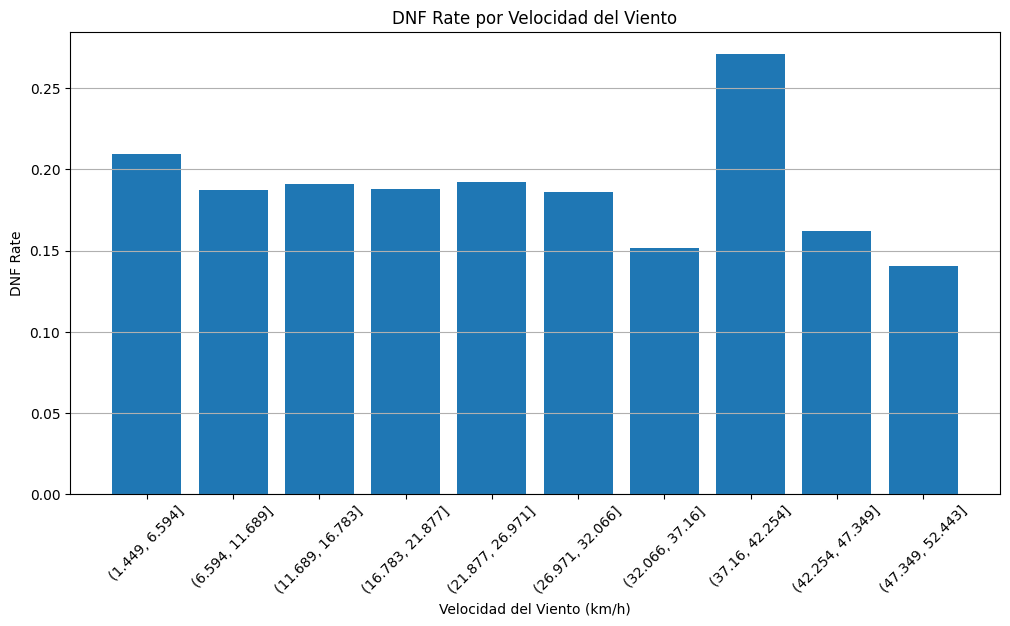

In [66]:
#calcular dnf_rate por tipo de circuito
circuit_dnf_rate = df.groupby('circuit_type')['dnf_rate'].mean().reset_index()
# Graficar el dnf_rate por tipo de circuito
plt.figure(figsize=(12, 6)) 
plt.bar(circuit_dnf_rate['circuit_type'], circuit_dnf_rate['dnf_rate'])
plt.title('DNF Rate por Tipo de Circuito')
plt.xlabel('Tipo de Circuito')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

#calcular dnf_rate por clima
climate_dnf_rate = df.groupby('isRainy')['dnf_rate'].mean().reset_index()
# Graficar el dnf_rate por clima
plt.figure(figsize=(12, 6))
plt.bar(climate_dnf_rate['isRainy'].astype(str), climate_dnf_rate['dnf_rate'], color=['blue', 'orange'])
plt.title('DNF Rate por Clima')
plt.xlabel('Clima (0 = No Lluvia, 1 = Lluvia)')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

#calcular dnf_rate por temperatura
temperature_bins = pd.cut(df['temperature_C'], bins=10)
temperature_dnf_rate = df.groupby(temperature_bins)['dnf_rate'].mean().reset_index()
# Graficar el dnf_rate por temperatura
plt.figure(figsize=(12, 6))
plt.bar(temperature_dnf_rate['temperature_C'].astype(str), temperature_dnf_rate['dnf_rate'])
plt.title('DNF Rate por Temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

#calcular dnf_rate por humedad
humidity_bins = pd.cut(df['humidity_pct'], bins=10)
humidity_dnf_rate = df.groupby(humidity_bins)['dnf_rate'].mean().reset_index()
# Graficar el dnf_rate por humedad
plt.figure(figsize=(12, 6))
plt.bar(humidity_dnf_rate['humidity_pct'].astype(str), humidity_dnf_rate['dnf_rate'])
plt.title('DNF Rate por Humedad')
plt.xlabel('Humedad (%)')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

#calcular dnf_rate por velocidad del viento
wind_speed_bins = pd.cut(df['wind_speed_kmh'], bins=10)
wind_speed_dnf_rate = df.groupby(wind_speed_bins)['dnf_rate'].mean().reset_index()
# Graficar el dnf_rate por velocidad del viento
plt.figure(figsize=(12, 6))
plt.bar(wind_speed_dnf_rate['wind_speed_kmh'].astype(str), wind_speed_dnf_rate['dnf_rate'])
plt.title('DNF Rate por Velocidad del Viento')
plt.xlabel('Velocidad del Viento (km/h)')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# circuito con menos dnf (mas faciles)

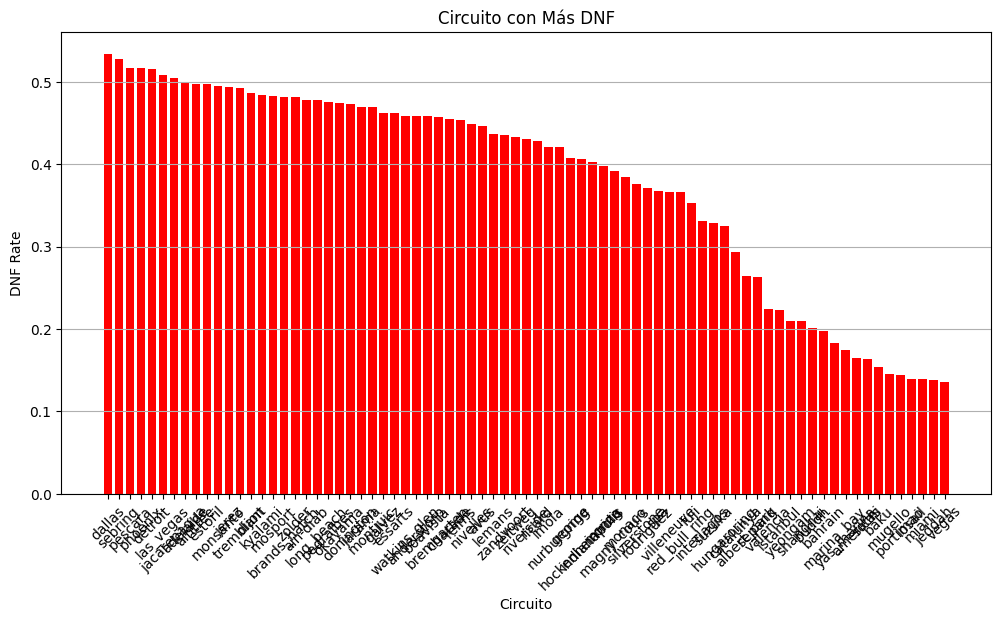

In [7]:
#circuito con mas dnf
circuit_dnf = df.groupby('circuitRef')['dnf_rate'].mean().reset_index()
circuit_dnf = circuit_dnf.sort_values(by='dnf_rate', ascending=False)
# Graficar el circuito con más DNF
plt.figure(figsize=(12, 6))
plt.bar(circuit_dnf['circuitRef'], circuit_dnf['dnf_rate'], color='red')
plt.title('Circuito con Más DNF')
plt.xlabel('Circuito')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

C:\Users\tomas\AppData\Local\Temp\ipykernel_19272\572491110.py:6: DtypeWarning: Columns (6,28,41,46,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dataset/F1_Datos_limpios.csv")


No se encontraron pares de variables con correlación > 0.80.


C:\Users\tomas\AppData\Local\Temp\ipykernel_32052\1713115968.py:6: DtypeWarning: Columns (6,28,41,46,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dataset/F1_Datos_limpios.csv")


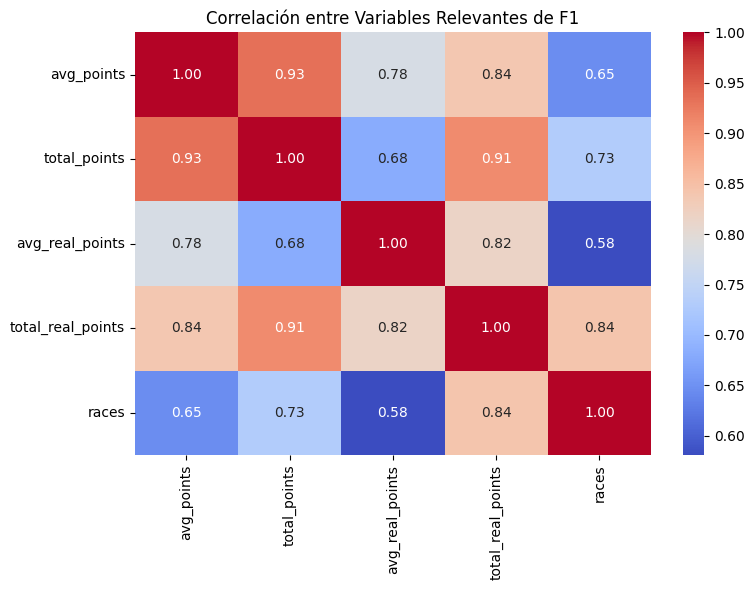

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV
df = pd.read_csv("../dataset/F1_Datos_limpios.csv")

# Filtrar variables relevantes
vars_to_keep = [
    'avg_points', 'total_points', 'avg_real_points',
    'total_real_points', 'races'
]
df_filtered = df[vars_to_keep].copy()

# Convertir a numérico y limpiar
df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')
df_filtered.dropna(inplace=True)

# Heatmap reducido
plt.figure(figsize=(8, 6))
sns.heatmap(df_filtered.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre Variables Relevantes de F1")
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
numeric_cols = df.select_dtypes(include=['number']).columns
df_numeric = df[numeric_cols]

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()
corr_pairs = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

# Renombrar columnas
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlación']

# Filtrar por correlación mayor a 0.80 (positiva o negativa)
high_corr_pairs = corr_pairs[(abs(corr_pairs['Correlación']) > 0.80) & (abs(corr_pairs['Correlación']) != 1)]

# Ordenar por valor de correlación descendente
high_corr_pairs = high_corr_pairs.sort_values(by='Correlación', ascending=False)

# Mostrar tabla
print(high_corr_pairs.to_string(index=False))


              Variable 1              Variable 2  Correlación
                position           positionOrder     0.999982
                  raceId                resultId     0.968033
                   round              race_month     0.957180
              avg_points            total_points     0.933538
            total_points       total_real_points     0.909655
       total_real_points                    wins     0.898683
  last_n_avg_gap_to_team         avg_gap_to_team     0.895409
                  raceId               race_year     0.880078
                    wins                win_rate     0.865490
         avg_real_points                win_rate     0.860539
       total_real_points                   races     0.842808
              avg_points       total_real_points     0.839327
                resultId               race_year     0.836750
last_n_avg_gap_to_leader       avg_gap_to_leader     0.824440
            total_points                    wins     0.819672
        